# Baseline v0 — per-connector summary statistics

**SPEC Day 5, Akhil Task 3.** For each connector with enough normal sessions,
compute per-connector mean/std of the session-scale features and save them as
`models/baselines_v0.pkl`. This is a summary-stat baseline, not an Isolation
Forest — that lands Day 6.

**Data caveats (docs/data_audit_v0.md):**
- Flag 7: the delivered `data/reference/normal_sessions.csv` holds 10,090 sessions
  across 38 connectors — not the 23,084 / 46 from the original audit. Recounted
  per connector: heavy (≥1000) **1**, medium **20**. The SPEC's "7 heavy-tier
  connectors" refers to the full audit set, so this notebook baselines **all 22
  connectors with ≥100 sessions** and must be re-run when the full export lands.
- Flag 6: the capped raw export carries only `meter_reading_wh`, so energy features
  are computable only for the small subset of sessions present in the capped
  `data/raw/meter_values.csv`; duration is computable for all 10,090.


In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sessions = pd.read_csv(ROOT / 'data' / 'reference' / 'normal_sessions.csv',
                       parse_dates=['start_timestamp', 'stop_timestamp'])
sessions['duration_sec'] = (
    sessions['stop_timestamp'] - sessions['start_timestamp']
).dt.total_seconds()
print(f'{len(sessions)} sessions, {sessions.connector_pk.nunique()} connectors')
sessions.head(3)

10090 sessions, 38 connectors


,transaction_pk,connector_pk,hashed_charge_box_id,physical_plug_id,start_timestamp,stop_timestamp,stop_reason,duration_sec
0,67729,2013696,0c70c6b0569cfdc7dda646e2d5a229f3f0063113fcc87a...,0,2026-04-23 13:29:30.920,2026-04-23 13:29:40,Other,9.08
1,57434,2009529,0c70c6b0569cfdc7dda646e2d5a229f3f0063113fcc87a...,1,2026-04-02 02:51:11.260,2026-04-02 03:12:25,Remote,1273.74
2,57450,2009529,0c70c6b0569cfdc7dda646e2d5a229f3f0063113fcc87a...,1,2026-04-02 03:58:46.260,2026-04-02 05:00:44,Remote,3717.74


## Tier check (flag 7 recount)

In [2]:
counts = sessions.groupby('connector_pk').size().sort_values(ascending=False)
tiers = pd.cut(counts, bins=[0, 30, 100, 1000, np.inf],
               labels=['sparse/marginal', 'light', 'medium', 'heavy'])
print(tiers.value_counts().sort_index())
baseline_connectors = counts[counts >= 100].index.tolist()
print(f'\nbaselining {len(baseline_connectors)} connectors with >=100 sessions')
counts.head(12)

sparse/marginal     6
light              11
medium             20
heavy               1
Name: count, dtype: int64

baselining 22 connectors with >=100 sessions


connector_pk
2963101    1047
2363324     971
2009530     880
2009529     861
2963102     843
2363325     712
4994561     538
2036074     482
4994560     442
3294791     373
2731433     320
2363331     316
dtype: int64

## Energy features from the capped raw export

Join `data/raw/meter_values.csv` by `transaction_pk`; energy = last − first
register reading, needing ≥2 readings per session. Coverage is limited by the cap.

In [3]:
meters = pd.read_csv(ROOT / 'data' / 'raw' / 'meter_values.csv',
                     parse_dates=['timestamp'])
reg = (meters.sort_values('timestamp')
       .groupby('transaction_pk')['meter_reading_wh']
       .agg(first='first', last='last', n='size'))
reg = reg[reg['n'] >= 2]
reg['energy_wh'] = reg['last'] - reg['first']
sessions = sessions.merge(reg[['energy_wh']], left_on='transaction_pk',
                          right_index=True, how='left')
sessions['energy_per_second'] = np.where(
    (sessions['duration_sec'] > 0) & sessions['energy_wh'].notna(),
    sessions['energy_wh'] / sessions['duration_sec'], np.nan)
covered = sessions['energy_wh'].notna().sum()
print(f'energy computable for {covered} of {len(sessions)} sessions '
      f'({covered / len(sessions):.1%} — capped export, flag 6)')

energy computable for 4 of 10090 sessions (0.0% — capped export, flag 6)


## Per-connector baselines (mean/std/n per feature)

In [4]:
FEATURES = ['duration_sec', 'energy_wh', 'energy_per_second']
subset = sessions[sessions.connector_pk.isin(baseline_connectors)]

baselines = {}
for connector_pk, group in subset.groupby('connector_pk'):
    baselines[int(connector_pk)] = {
        feature: {
            'mean': float(group[feature].mean()),
            'std': float(group[feature].std()),
            'n': int(group[feature].notna().sum()),
        }
        for feature in FEATURES
        if group[feature].notna().sum() >= 2
    }

summary = pd.DataFrame({
    pk: {f: f"{s['mean']:.0f}±{s['std']:.0f} (n={s['n']})"
         for f, s in feats.items()}
    for pk, feats in baselines.items()
}).T
summary

,duration_sec,energy_wh,energy_per_second
2009529,1473±1108 (n=861),10618470±12261153 (n=4),4730±5872 (n=4)
2009530,1385±1129 (n=880),NaN,NaN
2036074,1168±869 (n=482),NaN,NaN
2126185,2889±2355 (n=152),NaN,NaN
2363324,1539±1083 (n=971),NaN,NaN
2363325,1576±1067 (n=712),NaN,NaN
2363331,1333±1197 (n=316),NaN,NaN
2709616,3885±4074 (n=195),NaN,NaN
2731433,1510±1110 (n=320),NaN,NaN
2731434,1562±1111 (n=235),NaN,NaN


## Sanity checks — no all-zero features, no infinities

In [5]:
assert len(baselines) == len(baseline_connectors)
for pk, feats in baselines.items():
    assert 'duration_sec' in feats, f'{pk}: duration missing'
    for feature, stats in feats.items():
        assert np.isfinite(stats['mean']), f'{pk}.{feature}: non-finite mean'
        assert np.isfinite(stats['std']), f'{pk}.{feature}: non-finite std'
        assert stats['mean'] != 0 or feature != 'duration_sec', \
            f'{pk}: all-zero durations'
print(f'{len(baselines)} connector baselines pass sanity checks')

22 connector baselines pass sanity checks


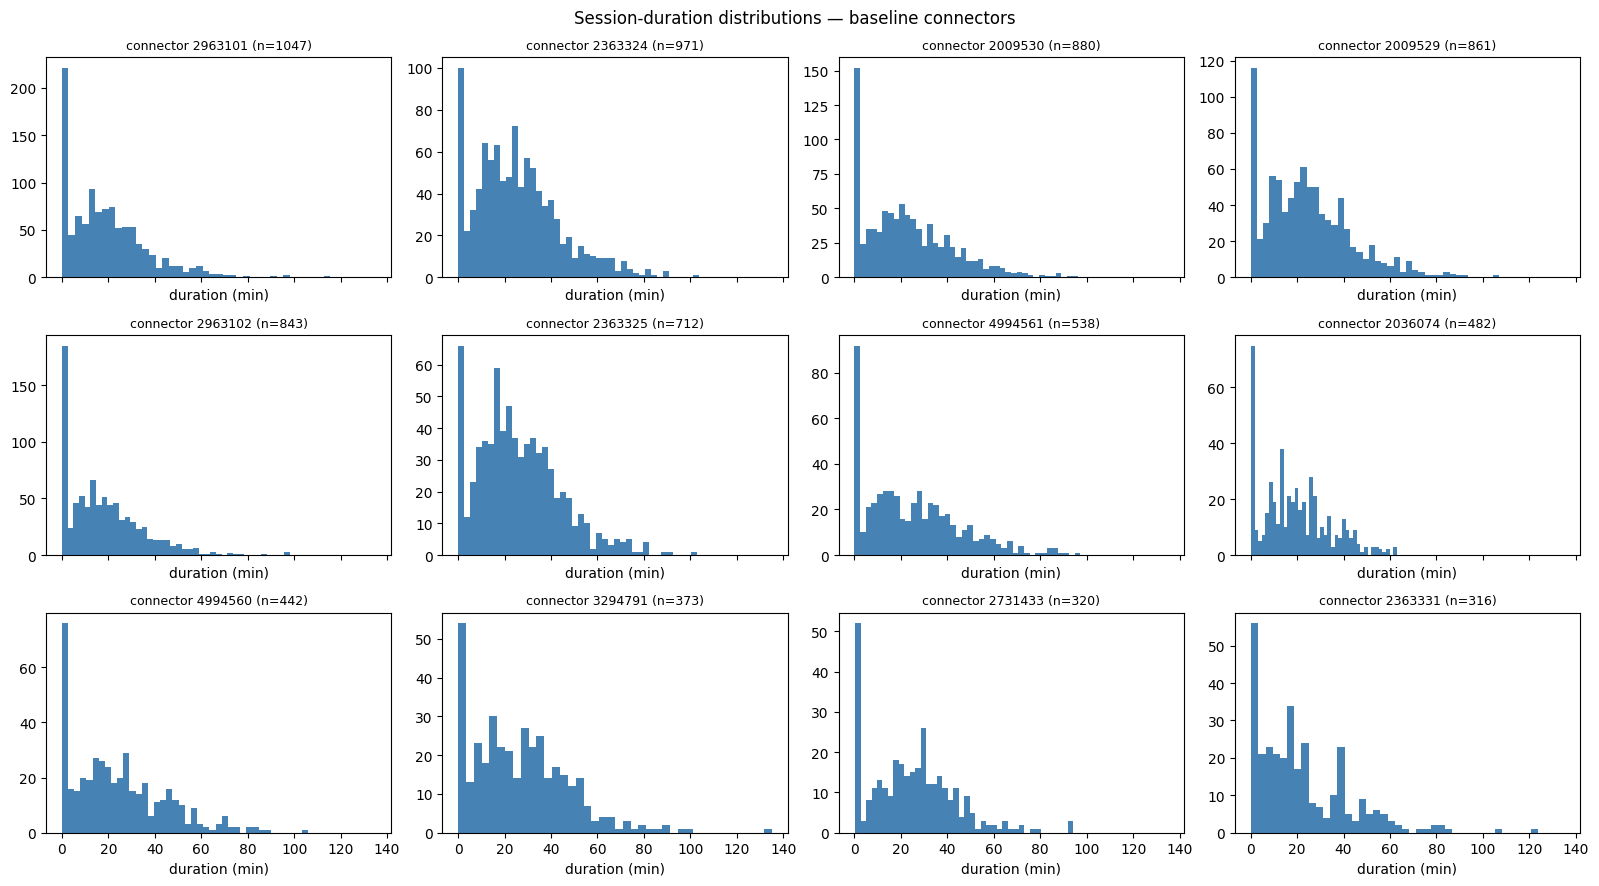

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9), sharex=True)
for ax, pk in zip(axes.flat, baseline_connectors):
    data = subset.loc[subset.connector_pk == pk, 'duration_sec'] / 60
    ax.hist(data, bins=40, color='steelblue')
    ax.set_title(f'connector {pk} (n={len(data)})', fontsize=9)
    ax.set_xlabel('duration (min)')
fig.suptitle('Session-duration distributions — baseline connectors')
fig.tight_layout()
plt.show()

## Save artifact

In [7]:
artifact = {
    'version': 'v0',
    'created': pd.Timestamp.now().isoformat(),
    'source': 'data/reference/normal_sessions.csv + capped data/raw/meter_values.csv',
    'note': ('summary-stat baseline over connectors with >=100 delivered normal '
             'sessions; re-run on the full export (audit flag 7) before trusting '
             'energy stats (flag 6 coverage)'),
    'features': FEATURES,
    'baselines': baselines,
}
out = ROOT / 'models' / 'baselines_v0.pkl'
with out.open('wb') as f:
    pickle.dump(artifact, f)
print(f'wrote {out} ({out.stat().st_size} bytes, '
      f'{len(baselines)} connectors x {len(FEATURES)} features)')

wrote h:\EV Asset Performance Management agent\models\baselines_v0.pkl (1370 bytes, 22 connectors x 3 features)
